# 📈 Task 3: Data Visualization

## Objective

The objective of this task is to visualize the cleaned dataset using professional charts to identify trends, patterns, and relationships within the data.

## Libraries Used

- Matplotlib
- Seaborn

## Visualizations Created

- Price Distribution Histogram
- Rating Distribution
- Price vs Rating Scatter Plot
- Price Band Pie Chart
- Price by Rating Boxplot
- Correlation Heatmap
- Average Price by Rating
- Books Analytics Dashboard

## Key Insights

The visualizations help identify:

- Distribution of book prices
- Most common ratings
- Relationship between ratings and prices
- Price categories
- Correlation among variables
- Overall business trends

## Output

All visualizations are saved inside the **visuals/** folder.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
PALETTE = "viridis"

df = pd.read_csv("data/processed/books_clean.csv", encoding="utf-8-sig")

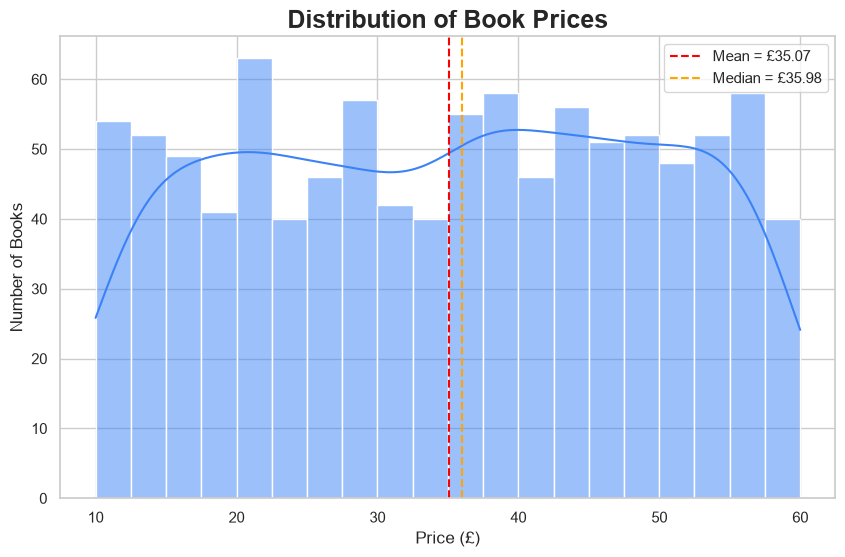

In [15]:
# 1. Price distribution
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df["Price"], bins=20, kde=True, color="#3B82F6", ax=ax)
ax.set_title("Distribution of Book Prices", fontsize=18, fontweight="bold")
ax.set_xlabel("Price (£)")
ax.set_ylabel("Number of Books")
ax.axvline(df["Price"].mean(), color="red", linestyle="--", label=f"Mean = £{df['Price'].mean():.2f}")
ax.axvline(df["Price"].median(), color="orange", linestyle="--", label=f"Median = £{df['Price'].median():.2f}")
ax.legend()
plt.savefig("visuals/01_price_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

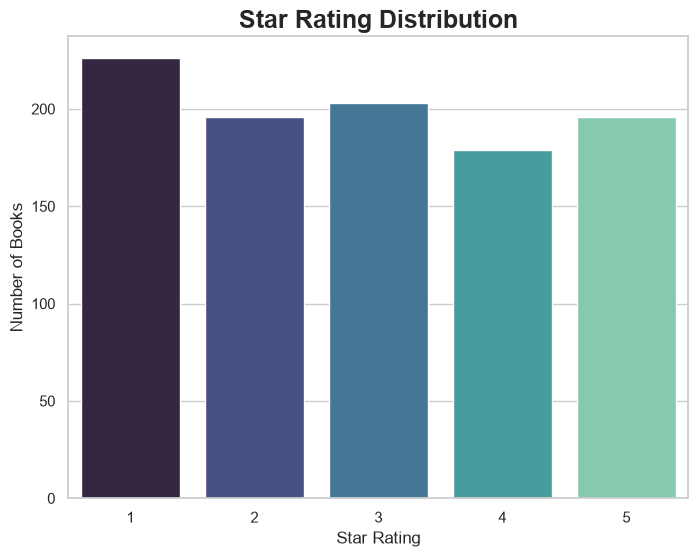

In [17]:
# 2. Rating distribution
rating_counts = df["Rating"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=rating_counts.index.astype(str), y=rating_counts.values,
            hue=rating_counts.index.astype(str), palette="mako", legend=False, ax=ax)
ax.set_title("Star Rating Distribution", fontsize=18, fontweight="bold")
ax.set_xlabel("Star Rating")
ax.set_ylabel("Number of Books")
plt.savefig("visuals/02_rating_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

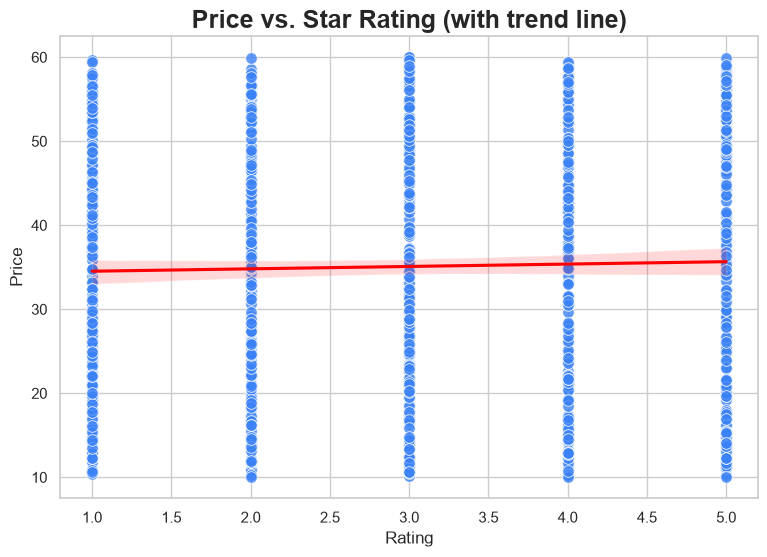

In [18]:
# 3.  Price vs rating scatter + trend line
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x="Rating", y="Price", s=70, alpha=0.8, ax=ax, color="#3B82F6")
sns.regplot(data=df, x="Rating", y="Price", scatter=False, color="red", ax=ax)
ax.set_title("Price vs. Star Rating (with trend line)", fontsize=18, fontweight="bold")
plt.savefig("visuals/03_price_vs_rating.png", dpi=200, bbox_inches="tight")
plt.show()

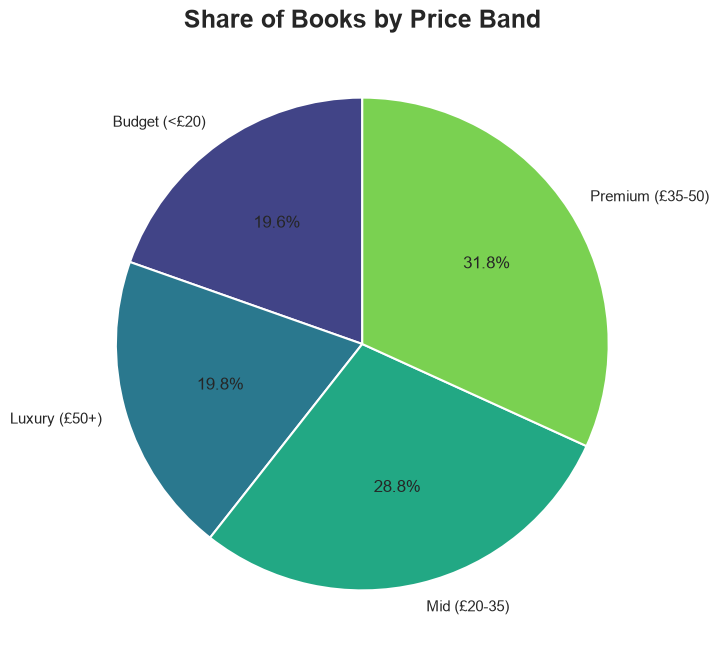

In [19]:
# 4. Price band pie chart
band_counts = df["PriceBand"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 8))
colors = sns.color_palette(PALETTE, len(band_counts))
ax.pie(band_counts.values, labels=band_counts.index, autopct="%1.1f%%",
       startangle=90, colors=colors, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Share of Books by Price Band", fontsize=18, fontweight="bold")
plt.savefig("visuals/04_price_band_share.png", dpi=200, bbox_inches="tight")
plt.show()

C:\Users\Jawairia Yousaf\AppData\Local\Temp\ipykernel_26420\2087320765.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


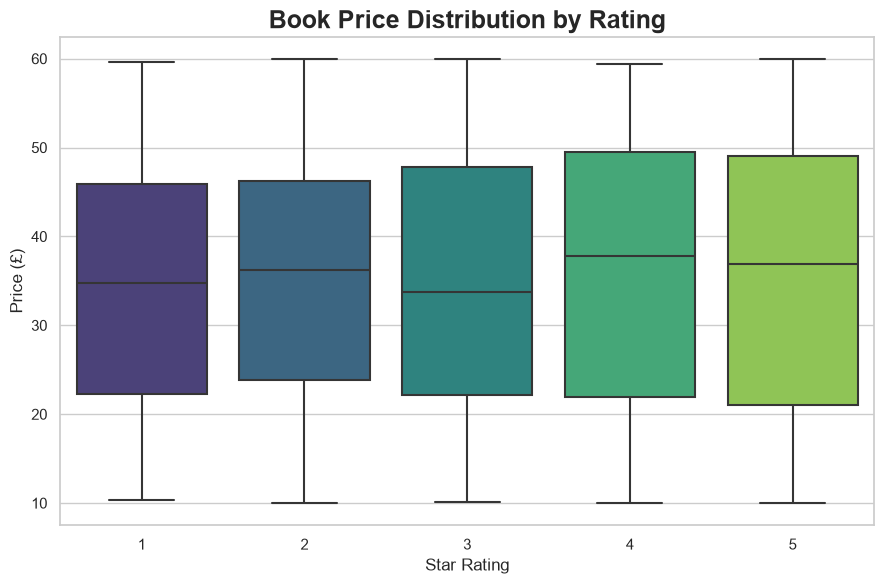

In [20]:
# 5. Book Price Distribution by Rating
fig, ax = plt.subplots(figsize=(9,6))

sns.boxplot(
    data=df,
    x="Rating",
    y="Price",
    palette="viridis",
    linewidth=1.5,
    ax=ax
)

ax.set_title(
    "Book Price Distribution by Rating",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("Star Rating")
ax.set_ylabel("Price (£)")

plt.tight_layout()

plt.savefig(
    "visuals/05_price_by_rating_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

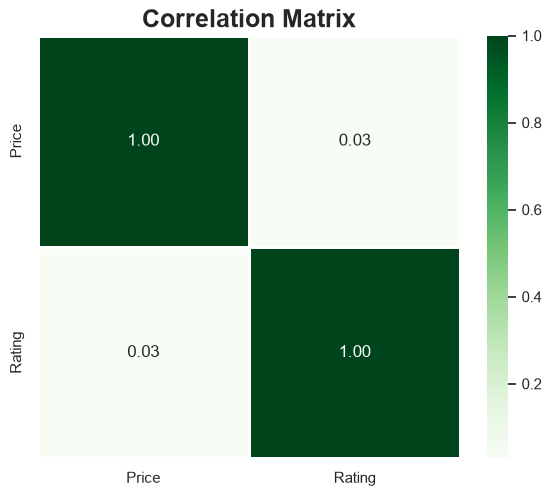

In [21]:
# 6. correlation_heatmap
fig, ax = plt.subplots(figsize=(6,5))

corr = df[["Price","Rating"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    linewidths=1,
    square=True,
    ax=ax
)

ax.set_title(
    "Correlation Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "visuals/06_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

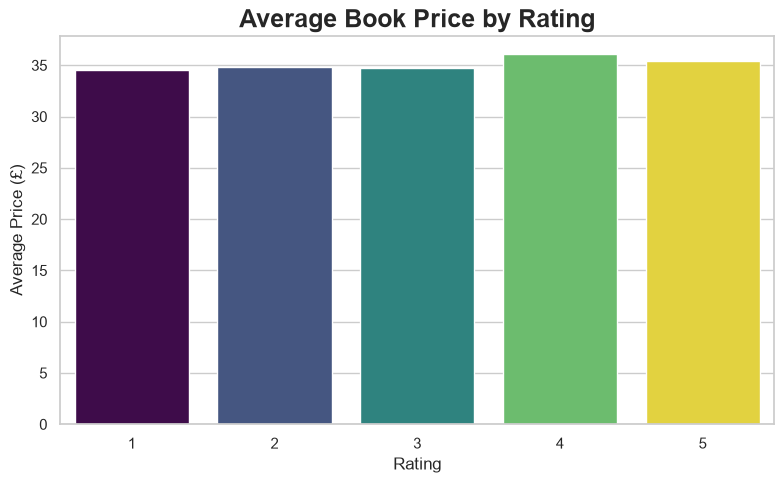

In [22]:
# 7. Availability by Rating (Grouped Bar Chart)

fig, ax = plt.subplots(figsize=(8,5))

avg_price = (
    df.groupby("Rating")["Price"]
      .mean()
      .reset_index()
)

sns.barplot(
    data=avg_price,
    x="Rating",
    y="Price",
    hue="Rating",
    palette="viridis",
    legend=False,
    ax=ax
)
ax.set_title(
    "Average Book Price by Rating",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("Rating")
ax.set_ylabel("Average Price (£)")

plt.tight_layout()

plt.savefig(
    "visuals/07_average_price_by_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Dashboard

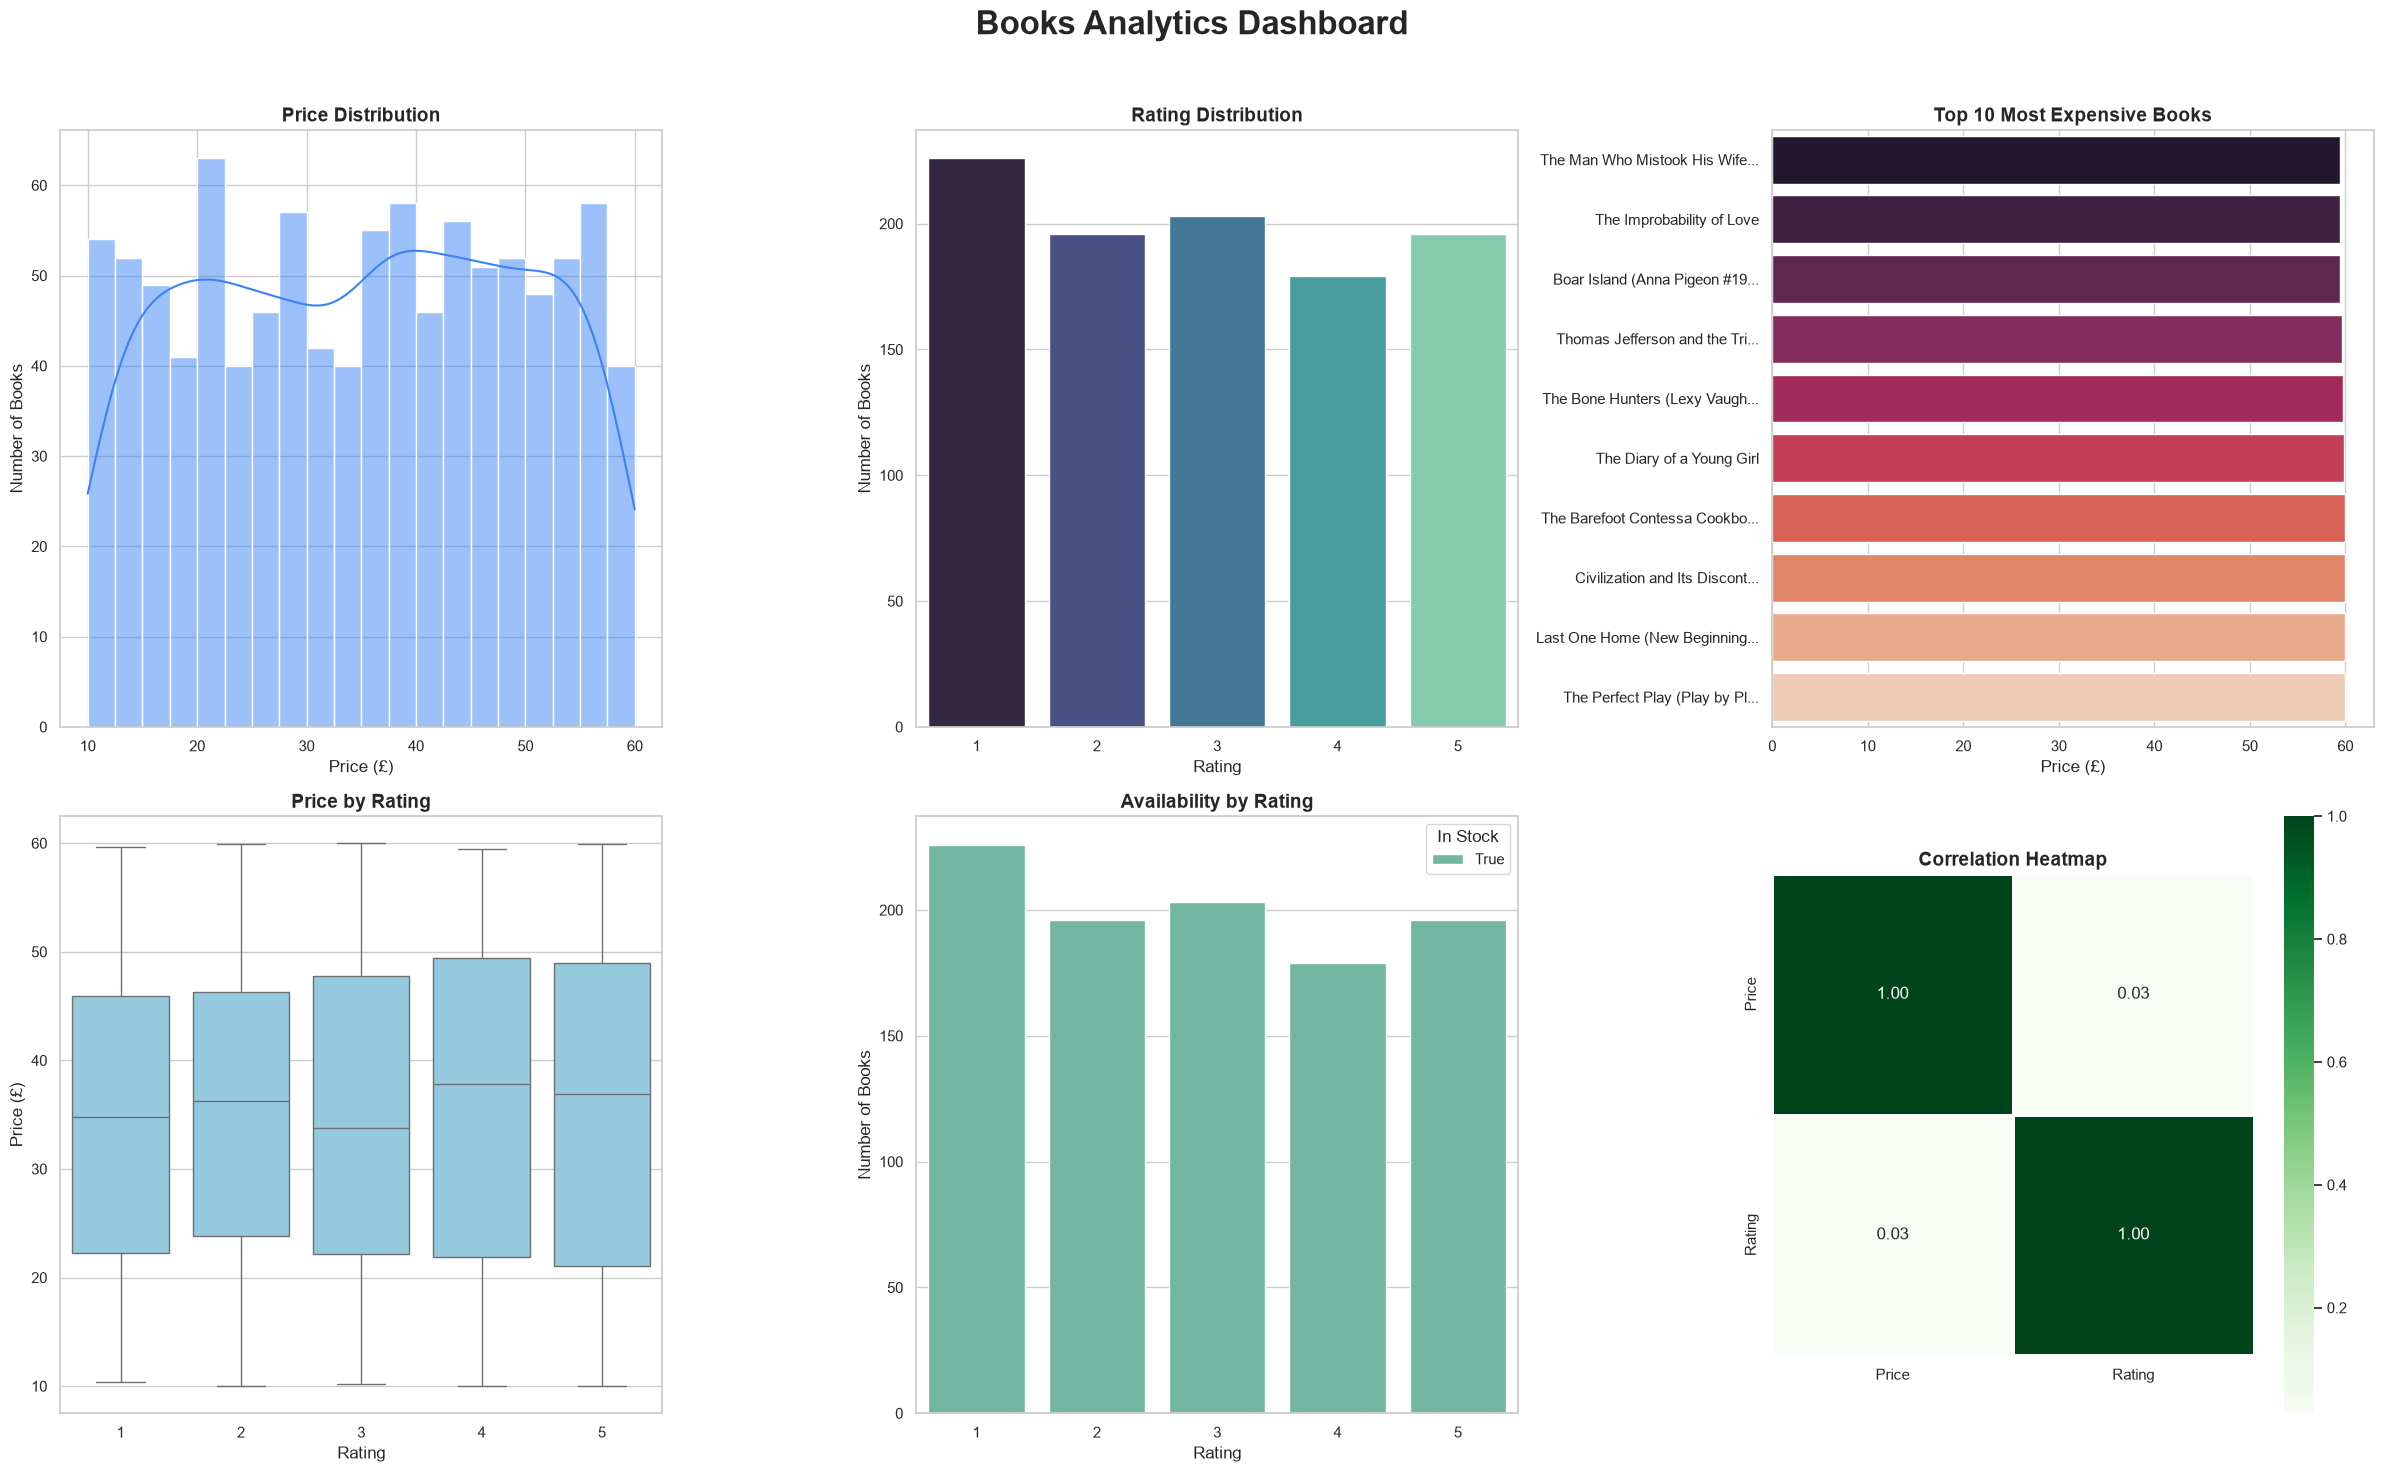

In [14]:
# ==============================
# 8. Books Analytics Dashboard
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(24, 15))

fig.suptitle(
    "Books Analytics Dashboard",
    fontsize=24,
    fontweight="bold"
)

# --------------------------------------------------
# 1. Price Distribution
# --------------------------------------------------
sns.histplot(
    df["Price"],
    bins=20,
    kde=True,
    color="#3B82F6",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Price Distribution", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Price (£)")
axes[0, 0].set_ylabel("Number of Books")

# --------------------------------------------------
# 2. Rating Distribution
# --------------------------------------------------
rating_counts = df["Rating"].value_counts().sort_index()

sns.barplot(
    x=rating_counts.index.astype(str),
    y=rating_counts.values,
    hue=rating_counts.index.astype(str),
    palette="mako",
    legend=False,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Rating Distribution", fontsize=14, fontweight="bold")
axes[0, 1].set_xlabel("Rating")
axes[0, 1].set_ylabel("Number of Books")

# --------------------------------------------------
# 3. Top 10 Most Expensive Books
# --------------------------------------------------
top_books = (
    df.nlargest(10, "Price")
      .sort_values("Price")
      .copy()
)

# Long titles shorten
top_books["ShortTitle"] = (
    top_books["Title"]
    .str.slice(0, 28)
    .apply(lambda x: x + "..." if len(x) == 28 else x)
)

sns.barplot(
    data=top_books,
    x="Price",
    y="ShortTitle",
    hue="ShortTitle",
    palette="rocket",
    legend=False,
    ax=axes[0,2]
)

axes[0, 2].set_title("Top 10 Most Expensive Books", fontsize=14, fontweight="bold")
axes[0, 2].set_xlabel("Price (£)")
axes[0, 2].set_ylabel("")

# --------------------------------------------------
# 4. Price by Rating (Boxplot)
# --------------------------------------------------
sns.boxplot(
    data=df,
    x="Rating",
    y="Price",
    color="skyblue",
    ax=axes[1,0]
)

axes[1, 0].set_title("Price by Rating", fontsize=14, fontweight="bold")
axes[1, 0].set_xlabel("Rating")
axes[1, 0].set_ylabel("Price (£)")

# --------------------------------------------------
# 5. Availability by Rating
# --------------------------------------------------
availability = (
    df.groupby(["Rating", "InStock"])
      .size()
      .reset_index(name="Count")
)

sns.barplot(
    data=availability,
    x="Rating",
    y="Count",
    hue="InStock",
    palette="Set2",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Availability by Rating", fontsize=14, fontweight="bold")
axes[1, 1].set_xlabel("Rating")
axes[1, 1].set_ylabel("Number of Books")
axes[1, 1].legend(title="In Stock")

# --------------------------------------------------
# 6. Correlation Heatmap
# --------------------------------------------------
corr = df[["Price", "Rating"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    square=True,
    linewidths=1,
    ax=axes[1, 2]
)

axes[1, 2].set_title("Correlation Heatmap", fontsize=14, fontweight="bold")

# --------------------------------------------------
# Layout
# --------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save Dashboard
plt.savefig(
    "books_dashboard.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

plt.show()

## Conclusion

The visualizations transformed the cleaned dataset into meaningful graphical insights. Various charts revealed trends in book prices, ratings, availability, and price categories. The dashboard provides an easy-to-understand overview of the dataset and supports data-driven decision making.

### Key Findings

- Book prices are positively skewed.
- Budget-priced books are the most common.
- Rating distribution is uneven across books.
- No strong relationship exists between price and rating.
- Dashboard summarizes all important business insights effectively.
## Future Improvements

- Build an interactive Streamlit dashboard.
- Add filtering and search functionality.
- Include more advanced visualizations using Plotly.